In [661]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import make_classification

In [662]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, class_sep=10, hypercube=False, random_state=41)

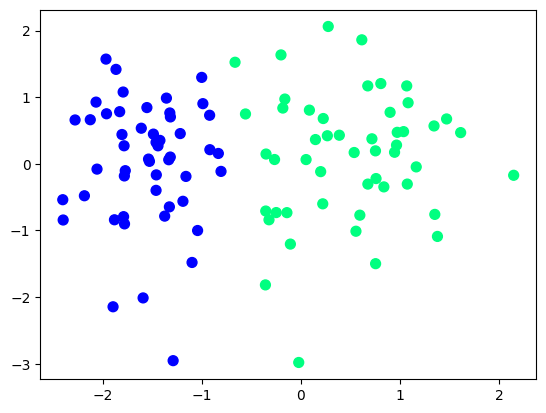

In [663]:
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=50)
plt.show()

## Perceptron Method - using formula

Using step function


In [664]:
def step_perceptron(X,y):
  X = np.insert(X, 0 , 1, axis = 1)
  W = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    s = np.random.randint(0, 100)
    y_hat = step(np.dot(X[s], W))
    W = W + lr * (y[s] - y_hat) * X[s]
  return W[0], W[1:]

def step(z):
  return 1 if z > 0 else 0


In [665]:
y_intersept, _coef = step_perceptron(X,y)

In [666]:
print(_coef)
print(y_intersept)

[1.39633238 0.21456685]
0.9


In [667]:
m = -(_coef[0] / _coef[1])
b = -(y_intersept / _coef[1])

In [668]:
X_input_step = np.linspace(-3, 3, 100)
y_input_step = m * X_input_step + b

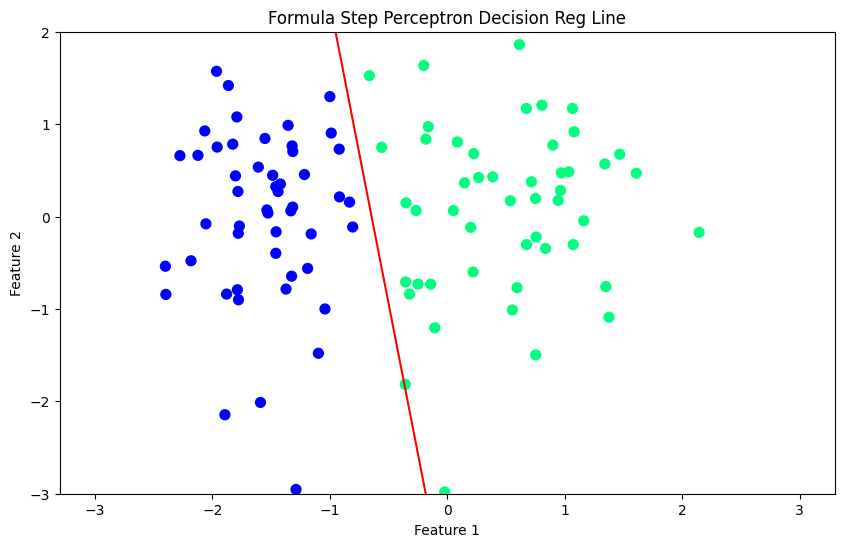

In [669]:
plt.figure(figsize=(10,6))
plt.plot(X_input_step, y_input_step, color='red', linestyle='-', label='Formula Perceptron Reg Line')
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=50)
plt.title('Formula Step Perceptron Decision Reg Line')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.ylim(-3,2)
plt.show()

Using Sigmoid function

In [670]:
def sigmoid_perceptron(X,y):
  X = np.insert(X, 0 , 1, axis = 1)
  W = np.ones(X.shape[1])
  lr = 5
  n_samples = X.shape[0]
  bias = 1

  for i in range(20000):
    y_hat = sigmoid(np.dot(X, W) + bias)

    dw = np.dot(X.T, (y_hat - y)) / n_samples
    db = np.sum(y_hat - y) / n_samples

    W = W - lr * dw
    bias = bias - lr * db
  return W, bias

def sigmoid(z):
  return 1 / (1 + np.exp(-z))  # using sigmoid function

In [671]:
W, bias = sigmoid_perceptron(X,y)

In [672]:
print(W)
print(bias)

[10.57683207 31.64713143  2.80538471]
10.576832068836149


In [673]:
m = -(W[1] / W[2])
b = -((W[0] + bias) / W[2])

In [674]:
X_input_sigmoid = np.linspace(-3, 3, 100)
y_input_sigmoid = m * X_input_sigmoid + b

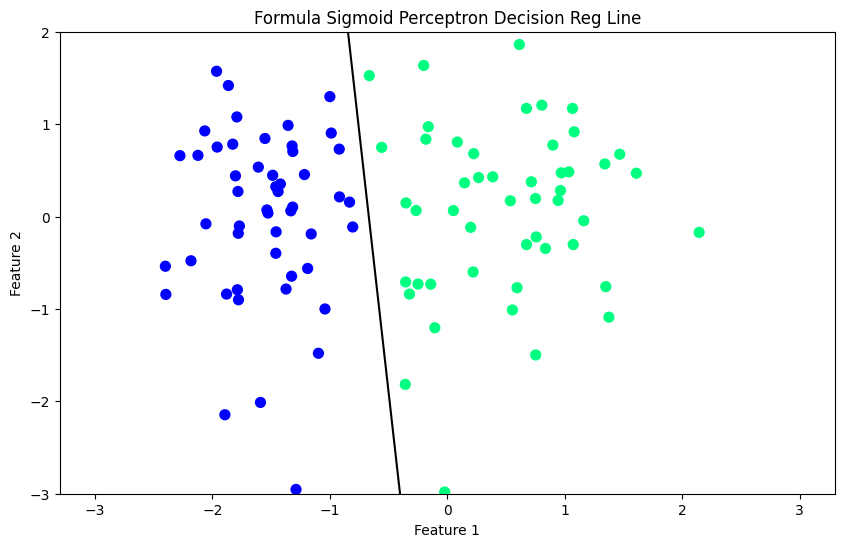

In [675]:
plt.figure(figsize=(10,6))
plt.plot(X_input_sigmoid, y_input_sigmoid, color='black', linestyle='-', label='Formula Perceptron Reg Line')
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=50)
plt.title('Formula Sigmoid Perceptron Decision Reg Line')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.ylim(-3,2)
plt.show()

## Using sklearn

In [676]:
from sklearn.linear_model import Perceptron

sk_perceptron = Perceptron(random_state=42)
sk_perceptron.fit(X, y)

Perceptron(random_state=42)

In [677]:
sk_coef = sk_perceptron.coef_[0]
sk_intercept = sk_perceptron.intercept_[0]

In [678]:
m_sk = -(sk_coef[0] / sk_coef[1])
b_sk = -(sk_intercept / sk_coef[1])

In [679]:
X_input_sk = np.linspace(-3, 3, 100)
y_input_sk = m_sk * X_input_sk + b_sk

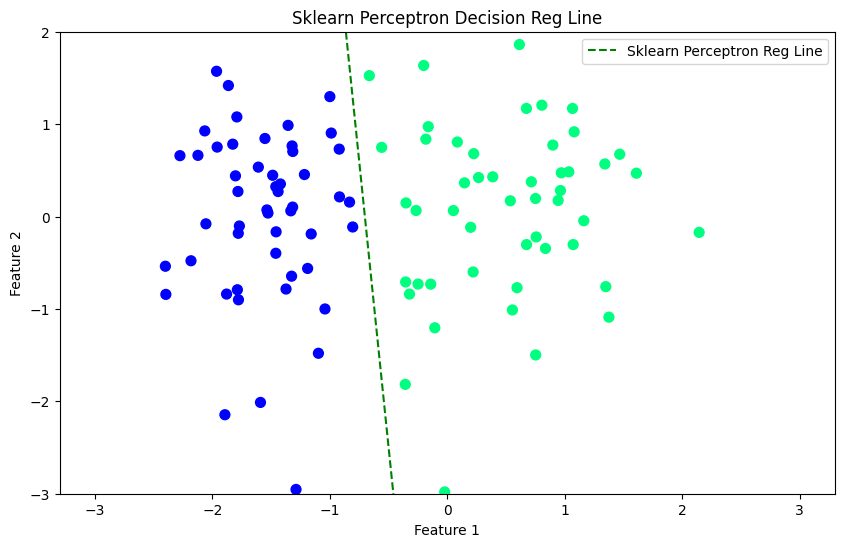

In [680]:
plt.figure(figsize=(10,6))
plt.plot(X_input_sk, y_input_sk, color='green', linestyle='--', label='Sklearn Perceptron Reg Line')
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=50)
plt.ylim(-3,2)
plt.title('Sklearn Perceptron Decision Reg Line')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

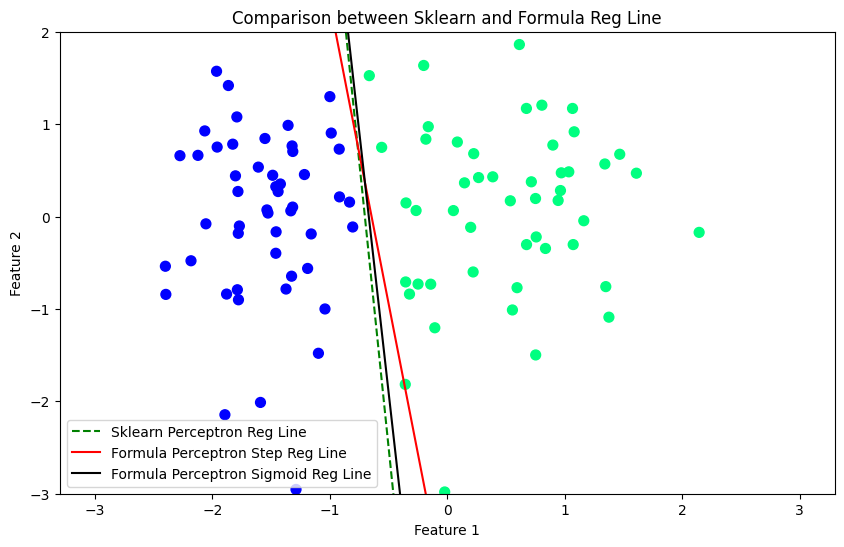

In [681]:
plt.figure(figsize=(10,6))
plt.plot(X_input_sk, y_input_sk, color='green', linestyle='--', label='Sklearn Perceptron Reg Line')
plt.plot(X_input_step, y_input_step, color='red', linestyle='-', label='Formula Perceptron Step Reg Line')
plt.plot(X_input_sigmoid, y_input_sigmoid, color='black', linestyle='-', label='Formula Perceptron Sigmoid Reg Line')
plt.scatter(X[:,0],X[:,1], c=y, cmap='winter',s=50)
plt.ylim(-3,2)
plt.title('Comparison between Sklearn and Formula Reg Line')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()